<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/GalaxyClassificationCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'> Morphological classification of galaxies with a convolution neural networks (CNN)

**by Alejandro Benitez-Llambay (alejandro.benitezllambay@unimib.it)** for the lab on "Signal and Imaging Acquisition and Modelling in Environment", of the Master in Artificial Inteligence for Science and Technology (AI4ST) at UNIMIB


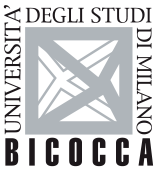

Today, we propose applying a convolutional neural network (CNN) model for classifying galaxies. While galaxies come in a variety of shapes (as seen in Hubble's galaxy classification scheme below), the simplest classification divides them into two broad categories: disk and spheroidal (or smooth) galaxies.

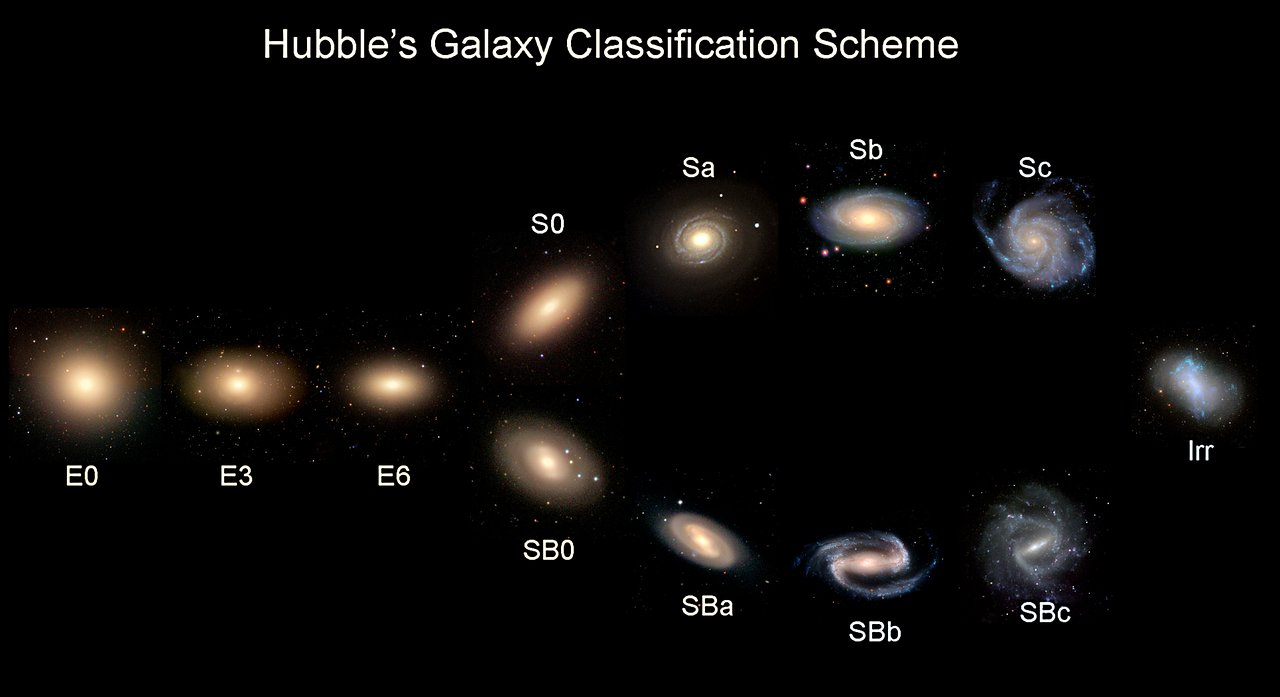

The classification of galaxies has traditionally been a human task, where trained astronomers visually examine galaxies one by one and classify them based on a set of criteria. However, with the advent of CNNs, this task has become increasingly automated, with human classification now serving as quality control, especially for unusual galaxy types.

Training CNNs, however, requires a wealth of data. This is where citizen science projects, such as Galaxy Zoo, play a crucial role. In these projects, volunteers help classify galaxies, and their inputs can later be used to train models.

Today, we propose using images classified by volunteers from the Galaxy Zoo (https://www.zooniverse.org/projects/zookeeper/galaxy-zoo/) project to train a CNN and then apply this model to classify new galaxies that we can find on the internet.

# The Data

We will be using images from the Galaxy Zoo 2 data release (https://zenodo.org/records/3565489#.Y3vFKS-l0eY) and https://data.galaxyzoo.org/

The dataset consists of more than 200,000 images, each containing 3 color channels that encode the *gri* SDSS filters, and each image is 424x424 pixels in size. For more details, you can refer to the original papers of the project:

https://doi.org/10.1093/mnras/stt1458

https://doi.org/10.1093/mnras/stw1588

For reasons that are not entirely clear, the released dataset does not include images for every galaxy. Therefore, we have cleaned the data for you and made it available here:

https://drive.google.com/drive/folders/1X9Q8ZJg0z_AxwEFxhpSCNkI4gO5VySWs?usp=drive_link

The best way to work with these data is to create a shortcut in your Google Drive and then mount the drive here.

In the shared directory, you will find four relevant files:

* **`images.zip`**: This file contains the full set of images in `jpg` format. Each image is labeled with its `asset_id`. Download this file to your computer if you prefer to work offline.

* **`assets.hdf5`**: This HDF5 file contains the images stored as raw bytes, organized in directories such as `assets/100`, where the number corresponds to the `asset_id`.

* **`gz2_clean.csv`**: This CSV file contains all the information for each galaxy classified in the Galaxy Zoo 2 data release. It includes various classification details, along with the `asset_id` of each image. The galaxy morphology can be determined based on the classification information provided in this file.

* **`gz2_info.txt`**: This file provides a brief explanation of the content in the `gz2_clean.csv` file.

# **YOUR TASK**

Your task is to leverage this incredible dataset to train a CNN that can classify galaxies as either disk or spheroidal (smooth). To do this, make sure to select galaxies that are likely well-classified. We propose splitting the sample into disk and smooth galaxies using the following criteria:

Define disk galaxies as those with:

`t01_smooth_or_features_a02_features_or_disk_fraction > 0.9` and `t01_smooth_or_features_a02_features_or_disk_count > 30`.

This ensures that more than 90% of volunteers agreed that the galaxy is a disk, and at least 30 individuals confirmed that the galaxy exhibits a disk structure.

Likewise, define smooth galaxies as those with:

`t01_smooth_or_features_a01_smooth_fraction > 0.9` and `t01_smooth_or_features_a01_smooth_count > 30`.

These criteria should result in **14419** disk
galaxies and **30670** smooth galaxies (i.e., **45089** galaxies of a total of **239,573** contained in the file).

Of course, you are free to change these criteria to add more noise in the classification and increase the sample.

In short, your taks for this project are:

* Familiarize yourself with the dataset
* Given your computational limitations, select a suitable sample of galaxies to train, validate and test the model.
* Study how the accuracy and the loss change as a function of the training epoch.
* Study the accuracy and the loss on a test sample.
* Using the test sample and the model predictions, study the confusion matrix.
* Apply your model to predict the morphology of galaxies found on internet.


#CONSIDERATIONS

If you run this exercise on your computer, it is unlikely that all the images will fit in memory. This is because, once the ```jpeg``` images are decoded, the minimum memory required to load each of them is:  

$S = W \times H \times C \times N_{\rm bytes} = 224 \times 224 \times 3 \times 4 \approx 0.6 \text{ MB}$

If your computer has 16 GB of RAM, you will be able to load only:  


$N_{\rm images} \approx \frac{16 \times 10^{3}}{0.6} = 26,666$

which is roughly 10% of the total dataset.  

Similarly, if you choose to work on Google Colab, similar constraints apply.  

These limitations are not specific to your computer or Google Colab; they are common across most computing environments. As Data Scientists, we often work at the limit of computational resources, and it is likely that similar constraints will apply to many state-of-the-art datasets you encounter.  

Therefore, we need to find a way to train the model without loading all the data into memory at once.  

Possible solutions to these limitations include training the model in batches, or helping Tensorflow undersatand how to load and decode the data in batches defining a ```tensorflow.Dataset``` object.

There are three possible solutions I can think of for this:


## 1) All the image assets are stored a ```jpg``` files in a directory.

This approach is acceptable if you are working on your own computer. If that is the case, you can create a ```tensorflow.Dataset``` as follows:

```python
def load_and_preprocess_image(image_file, label):    
    # Read the image
    img = tf.io.read_file(image_file)
    # Decode the bytes as a JPEG
    img = tf.image.decode_jpeg(img, channels=3)
    # Reduce the image size, for example
    img = tf.image.resize(img, (32, 32))
    # Normalize the image
    img = img / 255.0  # Normalize the image to [0, 1]

    # Return the image and its label    
    return img, label

ds_train = (
    tf.data.Dataset.from_tensor_slices((asset_files_train, labels_train))
    .map(lambda x, y: load_and_preprocess_image(x, y))
    .batch(32)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)
```

where ```asset_files_train``` is a list of file paths to the training images (e.g., ```['assets/002.jpg', 'assets/010.jpg']```, and ```labels_train``` is a list of their corresponding labels (e.g., ```[0,1]```).

Note that the `lambda` function is not needed in this case because `load_and_preprocess_image` already takes two arguments. If the function uses more than two arguments, then one should defined the `lambda` function.

Once the model is defined and compiled, training can be started with, e.g.,:

```
model.fit(ds_train, epochs=10, validation_data=ds_validation)
```


# 2) The images are stored in an HDF5 file

This approach is preferred if you do not want to overwhelm the file system, and in particular if you plan to work in Google Colab. In this case, the ```hdf5``` file provided contains the image raw bytes stored in different entries, each corresponding to a different ```asset_id```.

Individual images can be read and decoded as follows:

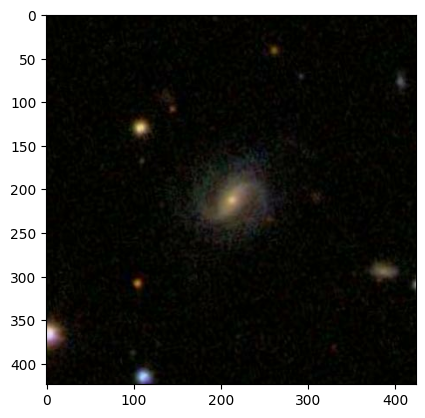

In [ ]:
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt

assets = h5py.File('/content/drive/MyDrive/Teaching/AI/Data/GalaxyZooData/assets.hdf5', 'r')
image = assets['assets/100132'][()]
image = tf.image.decode_jpeg(image, channels=3)
plt.imshow(image)

However, ```HDF5``` does not work directly with tensors, making it more challenging to create a general ```TensorFlow Dataset``` using an image reader involving ```HDF5```. I do not provide a code for this approach.

# 3) Write the training, validation and test samples as TensorFlow Records



For simplicity, I recommend storing the dataset as an intermediate ```TensorFlow Records``` file, which, like ```HDF5```, stores raw bytes but has the advantage of being fully compatible with TensorFlow.

To this end, I propose the following code snippets




``` python
# Create a dataset that is TF friendly:
with tf.io.TFRecordWriter('train.tfrecords') as writer:
  for i in tqdm(range(len(asset_files_train))):
    image_bytes = assets['%s'%asset_files_train[i]][()].tobytes()
    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_bytes])),
        'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[labels_train[i]]))
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    writer.write(example.SerializeToString())
```

This file can be used later on to generate a TensorFlow Dataset as follows:



```python
def parse_tfrecord(example_proto, augmentation):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }
    example = tf.io.parse_single_example(example_proto, feature_description)
    image = tf.io.decode_jpeg(example['image'], channels=3)
    image = tf.image.resize(image, (32, 32))
    image = image / 255.0
    label = example['label']
    return image, label

def create_dataset(tfrecord_file, shuffle=True, augmentation=True):
    dataset = tf.data.TFRecordDataset(tfrecord_file)
    dataset = dataset.map(lambda x: parse_tfrecord(x, augmentation), num_parallel_calls=tf.data.AUTOTUNE)    
    dataset = dataset.batch(32)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset
    
ds_train = create_dataset('/content/train.tfrecords')
    
ds_validation = create_dataset('/content/validation.tfrecords') #Assuming we created this file
```

We now should be able to use these data for training the model:

```python
model.fit(ds_train, epochs=10, validation_data=ds_validation)
```



As usual, at the end of the training process, you should check the `accuracy` and `loss` as as function of the training epoch. A typical plot for the accuracy should look similar to this:

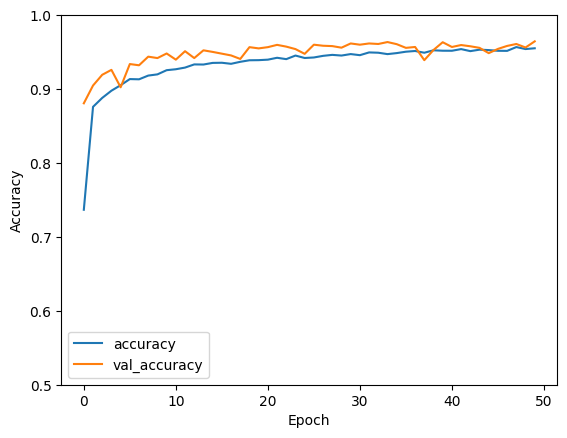

The confusion matrix applied to a test sample for a good model looks typically like this:

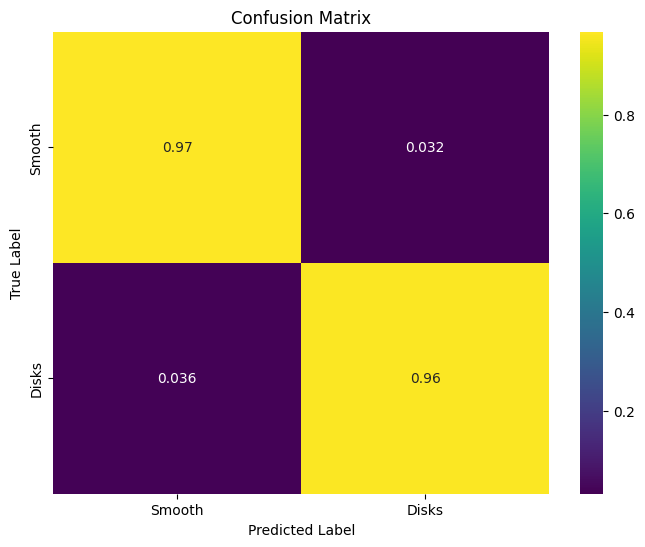

Finally, add random noise to the data to see how this precludes the model's ability to correclty classify the galaxies.

In [ ]:
# Your code should start here
#/////////////////////////////////////////


In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import h5py
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split


In [2]:
#connect to the drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/Environment/CNN/GalaxyCassification/data"

In [4]:
df = pd.read_csv(f"{dataset_path}/gz2_clean.csv")

In [5]:
df.head()

,dr7objid,ra,dec,rastring,decstring,sample_x,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag,objid,sample_y,asset_id
0,587732591714893851,179.04298,60.522520,b'11:56:10.32',b'+60:31:21.1',b'original',b'Sc+t',45,342,0,...,0,16,16.0,0.400,0.400,0.394506,0,587732591714893851,original,58957
1,588009368545984617,135.08440,52.494240,b'09:00:20.26',b'+52:29:39.3',b'original',b'Sb+t',42,332,1,...,0,13,13.0,0.317,0.323,0.322743,0,588009368545984617,original,193641
2,587732484359913515,183.37198,50.741510,b'12:13:29.27',b'+50:44:29.4',b'original',b'Ei',36,125,28,...,0,0,0.0,0.000,0.000,0.000000,0,587732484359913515,original,55934
3,587741723357282317,186.25195,28.558598,b'12:25:00.47',b'+28:33:31.0',b'original',b'Sc+t',28,218,1,...,0,6,6.0,0.240,0.240,0.239765,0,587741723357282317,original,158501
4,587738410866966577,161.08640,14.084465,b'10:44:20.73',b'+14:05:04.1',b'original',b'Er',43,151,33,...,0,0,0.0,0.000,0.000,0.000000,0,587738410866966577,original,110939


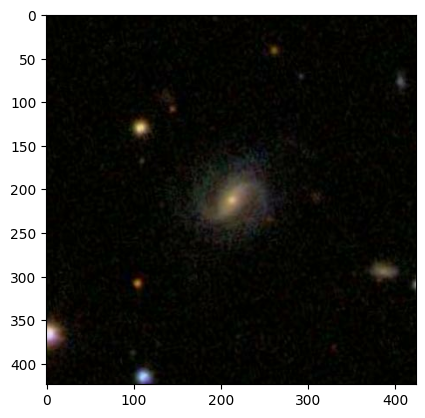

In [10]:
assets = h5py.File(f'{dataset_path}/assets.hdf5', 'r')
image = assets['assets/100132'][()]
image = tf.image.decode_jpeg(image, channels=3)
plt.imshow(image)

In [11]:
# get all the asset_ids
asset_ids = df['asset_id']

In [402]:
# get a list of  random  image form the dataset
size = 10000
random_idx = np.random.randint(0, len(asset_ids)+1, size=size)

In [451]:
# split the ids for training & testing
y_train_ids, y_test_ids = train_test_split(random_idx, test_size=0.2, shuffle=True)
y_train_ids, val_ids = train_test_split(y_train_ids, test_size=0.125, shuffle=True) # 10% of total dataset
y_train_ids.shape, y_test_ids.shape, val_ids.shape

((7000,), (2000,), (1000,))

**YOUR TASK**

Your task is to leverage this incredible dataset to train a CNN that can classify galaxies as either disk or spheroidal (smooth). To do this, make sure to select galaxies that are likely well-classified. We propose splitting the sample into disk and smooth galaxies using the following criteria:

Define disk galaxies as those with:

`t01_smooth_or_features_a02_features_or_disk_fraction > 0.9` and `t01_smooth_or_features_a02_features_or_disk_count > 30`.

This ensures that more than 90% of volunteers agreed that the galaxy is a disk, and at least 30 individuals confirmed that the galaxy exhibits a disk structure.

Likewise, define smooth galaxies as those with:

`t01_smooth_or_features_a01_smooth_fraction > 0.9` and `t01_smooth_or_features_a01_smooth_count > 30`.

In [407]:
df[['asset_id',
    't01_smooth_or_features_a02_features_or_disk_fraction',
    't01_smooth_or_features_a02_features_or_disk_count',
    't01_smooth_or_features_a01_smooth_fraction',
    't01_smooth_or_features_a01_smooth_count']].head()

,asset_id,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a02_features_or_disk_count,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a01_smooth_count
0,58957,0.933,42,0.000,0
1,193641,0.976,41,0.024,1
2,55934,0.139,5,0.778,28
3,158501,0.964,27,0.036,1
4,110939,0.186,8,0.767,33


In [452]:
# Create a tensor data generator
def data_generator(ids, assets):
    for idx in ids:
        img = assets[f'assets/{asset_ids[idx]}'][()]  # raw bytes
        img = bytes(img)
        criteria = df.iloc[idx][['t01_smooth_or_features_a02_features_or_disk_fraction',
                                 't01_smooth_or_features_a02_features_or_disk_count',
                                 't01_smooth_or_features_a01_smooth_fraction',
                                 't01_smooth_or_features_a01_smooth_count']].values
        label = None
        if criteria[0] > 0.9 and criteria[1]>30:
          label = 0 # galaxy is disk
        elif criteria[2] > 0.9 and criteria[3]>30:
          label = 1 # galaxy smooth
        if label is not None:
          label = np.array(label, dtype=np.float32)
          yield img, label   # (image_bytes, label)

In [453]:
# Creates train & test  Dataset whose elements are generated by generator
train_dataset = tf.data.Dataset.from_generator(lambda:data_generator(y_train_ids, assets),
                                          output_signature=(tf.TensorSpec(shape=(), dtype=tf.string), # image bytes
                                                            tf.TensorSpec(shape=(), dtype=tf.int16) # labels
                                          ))
test_dataset = tf.data.Dataset.from_generator(lambda:data_generator(y_test_ids, assets),
                                          output_signature=(tf.TensorSpec(shape=(), dtype=tf.string), # image bytes
                                                            tf.TensorSpec(shape=(), dtype=tf.int16) # labels
                                          ))

val_dataset = tf.data.Dataset.from_generator(lambda:data_generator(val_ids, assets),
                                          output_signature=(tf.TensorSpec(shape=(), dtype=tf.string), # image bytes
                                                            tf.TensorSpec(shape=(), dtype=tf.int16) # labels
                                          ))


In [454]:
# Create a preprocess function to decode, resize, normalize the image
def preprocess(image, label):
  image = tf.image.decode_jpeg(image, channels=3) # decode
  image = tf.image.resize(image, (32, 32)) # resize
  image = image/255.0
  return image, label

In [ ]:
# Create am augmentaion function
def augment(image, label):
    # Random brightness
    image = tf.image.random_brightness(image, max_delta=0.1)
    # # Random contrast
    # image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image, label

In [455]:
# Get the train & test dataset by parallel to preprocess
X_train = train_dataset
.map(map_func=preprocess, num_parallel_calls=tf.data.AUTOTUNE)
.map(map_fun=augment, num_parallel_calls=tf.data.AUTOTUNE) # <-- Apply agumentation

X_test = test_dataset.map(map_func=preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_dataset.map(map_func=preprocess, num_parallel_calls=tf.data.AUTOTUNE)
# # optimize the dataset
X_train = (X_train
           .shuffle(1000)
           .batch(32)
           .repeat() # continuous stream
           .prefetch(tf.data.AUTOTUNE)) # prefetch --> lazy loaded/caching

X_test  = (X_test
           .batch(32)
           .repeat()
           .prefetch(tf.data.AUTOTUNE))

val_data  = (val_data
           .batch(32)
           .repeat()
           .prefetch(tf.data.AUTOTUNE))

labels: [1 1 0] image shape: (32, 32, 32, 3)


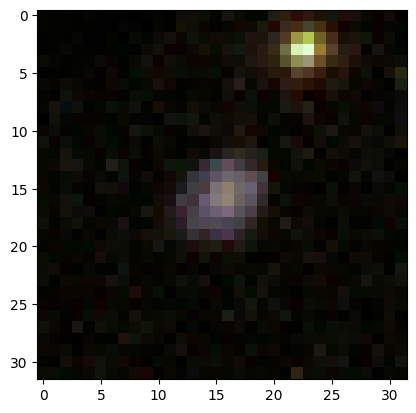

In [465]:
for image, label in val_data:
  print(f'labels: {label[:3]} image shape: {image.shape}')
  plt.imshow(image[np.random.randint(0, len(image)+1)])
  break

In [466]:
# Build the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3,
                           strides=(2,2), activation='relu', padding='same'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(filters=64, kernel_size=3,
                           strides=(2,2), activation='relu', padding='same'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(filters=128, kernel_size=3,
                           strides=(2,2), activation='relu', padding='same'),
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(units=1, activation='sigmoid')
])

In [467]:
# compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=['accuracy'])

In [468]:
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 1, 1, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [470]:
# train the model
train_steps_per_epoch = len(y_train_ids) // 32
val_steps_per_epoch = len(val_ids)//32

epochs = 10
history = model.fit(X_train, validation_data=X_test,
                    epochs=10, steps_per_epoch=train_steps_per_epoch,
                    validation_steps=val_steps_per_epoch)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 93s 387ms/step - accuracy: 0.6743 - loss: 0.6184 - val_accuracy: 0.6499 - val_loss: 0.5898
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 71s 326ms/step - accuracy: 0.7541 - loss: 0.4693 - val_accuracy: 0.7987 - val_loss: 0.4050
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 70s 322ms/step - accuracy: 0.8526 - loss: 0.3465 - val_accuracy: 0.8658 - val_loss: 0.3568
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 108s 499ms/step - accuracy: 0.8729 - loss: 0.3094 - val_accuracy: 0.8774 - val_loss: 0.3374
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 77s 356ms/step - accuracy: 0.8825 - loss: 0.2893 - val_accuracy: 0.8826 - val_loss: 0.3223
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 132s 607ms/step - accuracy: 0.8926 - loss: 0.2716 - val_accuracy: 0.8816 - val_loss: 0.3129
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 77s 356ms/step - accuracy: 0.8984 - loss: 0.2561 - val_accuracy: 0.8899 - val_loss: 0.2972
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 69s 320ms/step - accuracy: 0.9057 - loss:

<Axes: >

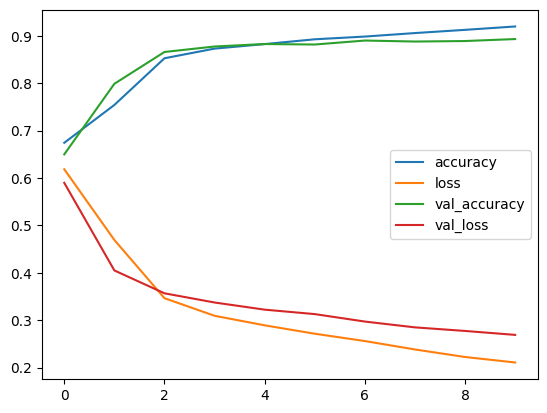

In [472]:
pd.DataFrame(history.history).plot()
